In [ ]:
import xarray as xr
import rioxarray
import numpy as np
from skimage.morphology import closing, remove_small_objects, disk
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape as shp
from shapely.ops import unary_union
import xvec

### Load the predictions and the cube for images

In [15]:
preds = xr.open_zarr("predictions.zarr")

cube = xr.open_zarr("fagra_2021_2023.zarr")
cube = cube.rio.write_crs("EPSG:32627")
transform = cube.rio.transform()

BANDS = ["red", "green", "blue", "nir", "swir16", "swir22"]

img = (cube[BANDS].to_array("band")
          .transpose("time", "band", "y", "x")
          .values.astype("float32")) / 10000.0
img = np.nan_to_num(np.clip(img, 0, 1))       # masked clouds -> 0

### Clean the masks

In [43]:
lava_raw = preds.lava.values.astype(bool)

MIN_PIXELS = 19        # 20 px * 100 m² = 2000 m² minimum mapping unit, max_size removes everything 4 and below

clean = np.stack([
    remove_small_objects(closing(m, disk(1)), max_size=MIN_PIXELS)
    for m in lava_raw
])

### Assign identity by eruption time

In [98]:
EPISODES = {
    "fagra_2021":  ("2021-03-01", "2021-10-30"),
    "fagra_2022":  ("2022-08-01", "2022-09-30"),
    "litli_2023":  ("2023-07-01", "2023-08-30"),
}

def active_episode(ts):
    for fid, (t0, t1) in EPISODES.items():
        if pd.Timestamp(t0) <= ts <= pd.Timestamp(t1):
            return fid
    return None

In [99]:
times = pd.to_datetime(preds.time.values)
shape = clean.shape[1:]

flow_cum = {fid: np.zeros(shape, bool) for fid in EPISODES}   # per-flow emplaced mask
ever_lava = clean[0].copy()          # t=0 baseline: pre-existing lava (pre-2021 flows)
snapshots = []                        # per-flow mask at each t

for t, ts in enumerate(times):
    if t > 0:
        new = clean[t] 
        fid = active_episode(ts)
        if fid is not None:
            flow_cum[fid] |= new              # adopt into the active flow
            ever_lava |= new                  # only adopted pixels enter the record
        # if fid is None: 'new' pixels are unexplained detections -> not adopted
    snapshots.append({f: flow_cum[f].copy() for f in EPISODES})

### Plot and check the outcome

Text(0.5, 1.0, 'Emplaced lava flows by episode')

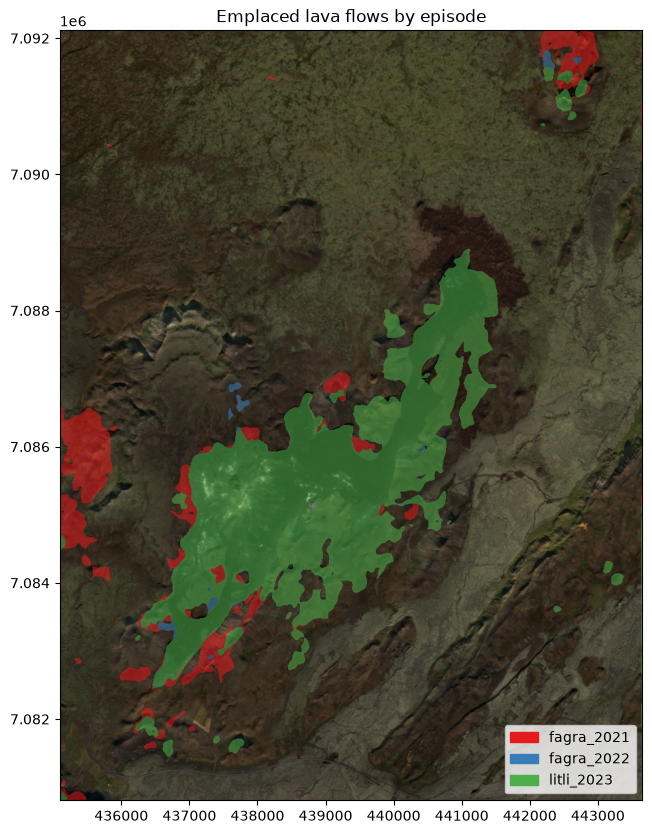

In [100]:
flows = list(EPISODES)
final = snapshots[-1]

code = np.zeros(shape, dtype="uint8")
for i, fid in enumerate(flows, start=1):
    code[final[fid]] = i

extent = [float(cube.x[0]), float(cube.x[-1]), float(cube.y[-1]), float(cube.y[0])]

colors = ["#e41a1c", "#377eb8", "#4daf4a"]          # one per flow
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(10, 10))
rgb = np.moveaxis(img[-2, :3], 0, -1) * 3          
ax.imshow(np.clip(rgb, 0, 1), extent=extent)
masked = np.ma.masked_where(code == 0, code)        # hide background
ax.imshow(masked, cmap=cmap, vmin=1, vmax=len(flows), alpha=0.55, extent=extent)
ax.legend(loc=4, handles=[Patch(color=c, label=f) for c, f in zip(colors, flows)])
ax.set_title("Emplaced lava flows by episode")

Plot area per flow

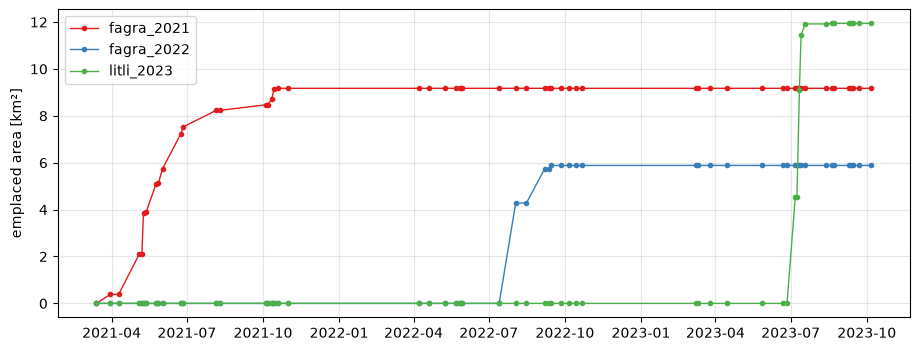

In [101]:
area = {fid: np.array([snap[fid].sum() * 100 / 1e6 for snap in snapshots])
        for fid in flows}                            # km²

fig, ax = plt.subplots(figsize=(11, 4))
for fid, c in zip(flows, colors):
    ax.plot(times, area[fid], color=c, label=fid, marker=".", lw=1)
ax.set_ylabel("emplaced area [km²]"); ax.legend(); ax.grid(alpha=0.3)

Plot specific dates to see if all flows evolve

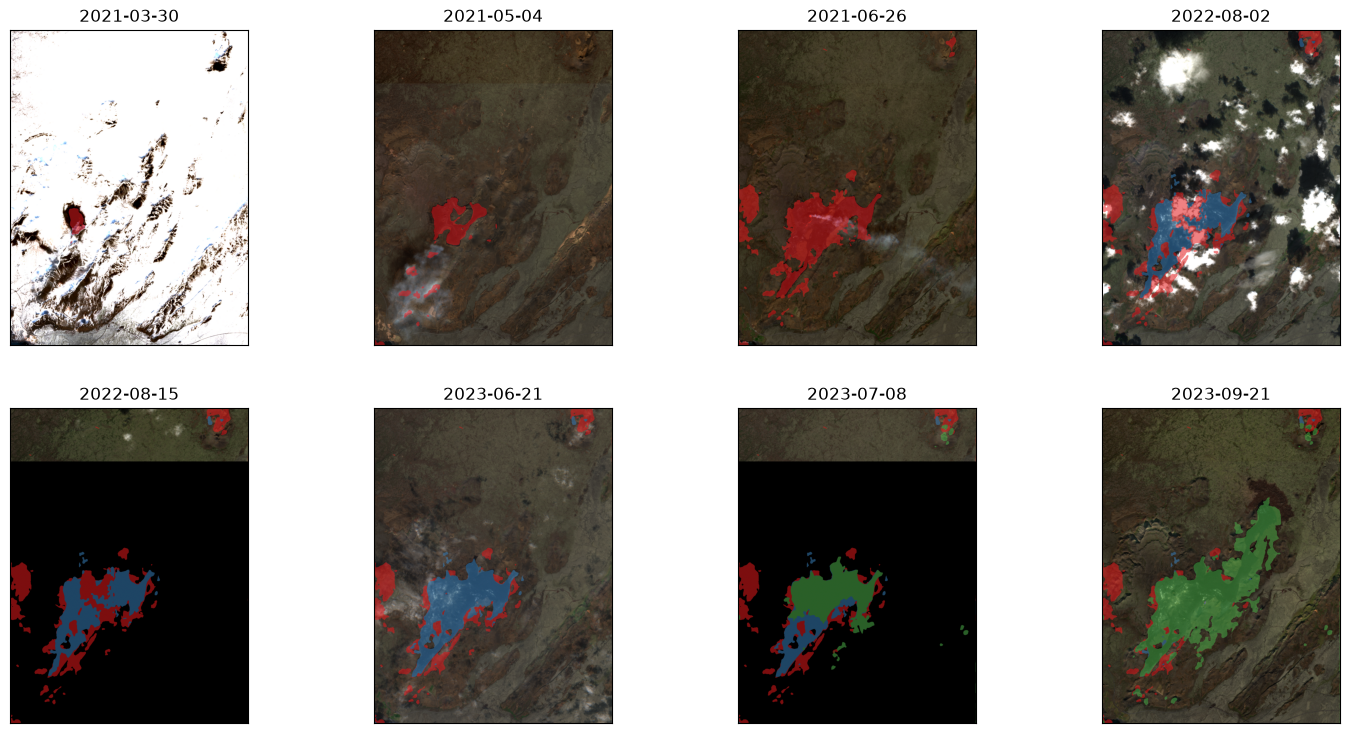

In [107]:
picks = [np.argmin(np.abs(times - pd.Timestamp(d))) for d in
         ["2021-04-01", "2021-05-01", "2021-07-15", "2022-08-01",
          "2022-08-20", "2023-06-15", "2023-07-10", str(times[-2].date())]]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, t in zip(axes.flat, picks):
    code_t = np.zeros(shape, dtype="uint8")
    for i, fid in enumerate(flows, start=1):
        code_t[snapshots[t][fid]] = i
    ax.imshow(np.clip(np.moveaxis(img[t, :3], 0, -1) * 3, 0, 1), extent=extent)
    ax.imshow(np.ma.masked_where(code_t == 0, code_t), cmap=cmap,
              vmin=1, vmax=len(flows), alpha=0.55, extent=extent)
    ax.set_title(str(times[t].date())); ax.set_xticks([]); ax.set_yticks([])

### Vectorize and build into VDC

In [108]:
def to_polygon(mask):
    """Binary mask -> single (Multi)Polygon in map coordinates, or None."""
    if not mask.any():
        return None
    geoms = [shp(g) for g, v in features.shapes(
                 mask.astype("uint8"), mask=mask, transform=transform) if v == 1]
    return unary_union(geoms)

In [138]:
flows = list(EPISODES)
T, F = len(times), len(flows)

geom = np.empty((F, T), dtype=object)
area = np.full((F, T), np.nan)

for t in range(T):
    for f, fid in enumerate(flows):
        poly = to_polygon(snapshots[t][fid])
        geom[f, t] = poly
        area[f, t] = poly.area / 1e6 if poly else 0.0     # km²

# your identity anchors: representative point of each flow's temporal union
anchors = [ (to_polygon(flow_cum[fid]).representative_point()
             if flow_cum[fid].any() else None) for fid in flows ]

vdc = xr.Dataset(
    {
        "area_km2": (("flow", "time"), area),
        "geometry": (("flow", "time"), geom),
    },
    coords={
        "flow": np.array(flows, dtype=object),   # object, not <U10
        "time": preds.time.values,
    },
)
vdc

<xarray.Dataset> Size: 3kB
Dimensions:   (flow: 3, time: 56)
Coordinates:
  * flow      (flow) object 24B 'fagra_2021' 'fagra_2022' 'litli_2023'
  * time      (time) datetime64[ns] 448B 2021-03-13T13:13:55.105000 ... 2023-...
Data variables:
    area_km2  (flow, time) float64 1kB 0.0 0.3855 0.3855 ... 11.94 11.94 11.94
    geometry  (flow, time) object 1kB None ... MULTIPOLYGON (((435140 7080910...

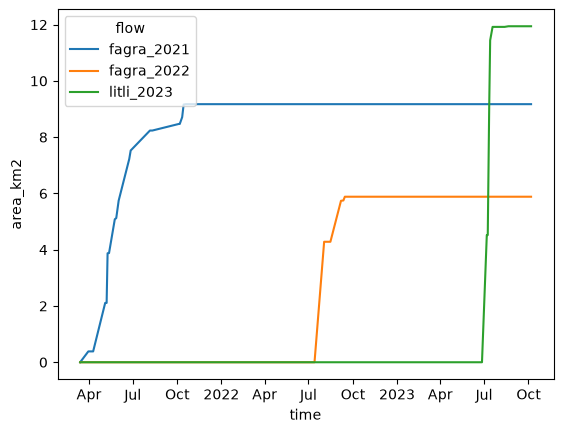

In [139]:
vdc.area_km2.plot.line(x="time", hue="flow")

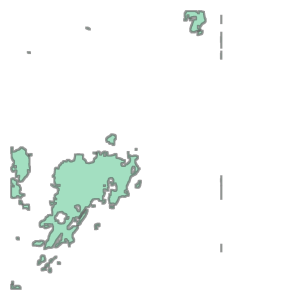

In [156]:
vdc.sel(flow="fagra_2021").isel(time=-1)["geometry"].item()

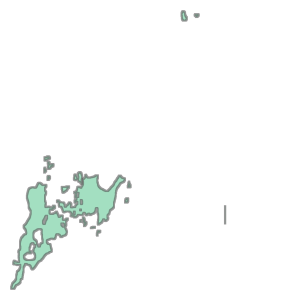

In [155]:
vdc.sel(flow="fagra_2022").isel(time=27)["geometry"].item()

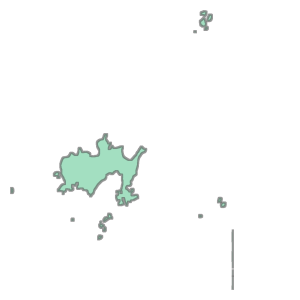

In [164]:
vdc.sel(flow="litli_2023").isel(time=43)["geometry"].item()